# 09 - Analise de dados obtidos via API

## Objetivo
Consolidar o que foi visto nos arquivos 01 a 08: consumir uma API, tratar
erros, paginar, salvar e analisar os dados com pandas e matplotlib.

## Fluxo do notebook
1. Coleta via API com tratamento de erro
2. Conversao para DataFrame
3. Limpeza e transformacao
4. Analise exploratoria (contagens, agrupamentos)
5. Visualizacao
6. Exportacao dos resultados

## API usada
jsonplaceholder.typicode.com, que simula posts, usuarios e comentarios.
Suficiente para praticar sem chave de autenticacao.

In [1]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

BASE = "https://jsonplaceholder.typicode.com"


def get_json(url, params=None, tentativas=3, espera=1.5):
    """GET com retentativas simples e tratamento de erro."""
    for tentativa in range(1, tentativas + 1):
        try:
            r = requests.get(url, params=params, timeout=8)
            r.raise_for_status()
            return r.json()
        except requests.exceptions.RequestException as e:
            print(f"[{tentativa}] Erro: {e}")
            if tentativa < tentativas:
                time.sleep(espera)
    return None

## 1. Coleta paginada

Vamos buscar todos os posts (100 no total) usando paginacao por _page/_limit.

In [2]:
def coletar_posts(por_pagina=25):
    todos = []
    pagina = 1
    while True:
        lote = get_json(f"{BASE}/posts", params={"_page": pagina, "_limit": por_pagina})
        if not lote:
            break
        todos.extend(lote)
        print(f"Pagina {pagina}: {len(lote)} itens (total {len(todos)})")
        if len(lote) < por_pagina:
            break
        pagina += 1
        time.sleep(0.1)
    return todos


posts = coletar_posts()
print("\nTotal de posts:", len(posts))

Pagina 1: 25 itens (total 25)
Pagina 2: 25 itens (total 50)
Pagina 3: 25 itens (total 75)
Pagina 4: 25 itens (total 100)

Total de posts: 100


In [3]:
# Outros recursos uteis
usuarios = get_json(f"{BASE}/users")
comentarios = get_json(f"{BASE}/comments")

print("Usuarios:", len(usuarios) if usuarios is not None else 0)
print("Comentarios:", len(comentarios) if comentarios is not None else 0)

Usuarios: 10
Comentarios: 500


## 2. Conversao para DataFrame

Cada post tem userId, id, title e body. Convertendo a lista de dicionarios
em DataFrame fica facil agrupar e analisar.

In [4]:
df_posts = pd.DataFrame(posts)
df_users = pd.DataFrame(usuarios)
df_comments = pd.DataFrame(comentarios)

print(df_posts.head())
print("\nInfo:")
print(df_posts.dtypes)

   userId  id                                              title  \
0       1   1  sunt aut facere repellat provident occaecati e...   
1       1   2                                       qui est esse   
2       1   3  ea molestias quasi exercitationem repellat qui...   
3       1   4                               eum et est occaecati   
4       1   5                                 nesciunt quas odio   

                                                body  
0  quia et suscipit\nsuscipit recusandae consequu...  
1  est rerum tempore vitae\nsequi sint nihil repr...  
2  et iusto sed quo iure\nvoluptatem occaecati om...  
3  ullam et saepe reiciendis voluptatem adipisci\...  
4  repudiandae veniam quaerat sunt sed\nalias aut...  

Info:
userId    int64
id        int64
title       str
body        str
dtype: object


## 3. Limpeza e transformacao

- Renomear colunas para clareza
- Calcular comprimento do titulo e do corpo
- Juntar com o nome do usuario

In [5]:
df_posts = df_posts.rename(columns={"id": "post_id", "userId": "user_id"})
df_posts["tamanho_titulo"] = df_posts["title"].str.len()
df_posts["tamanho_corpo"] = df_posts["body"].str.len()

# Juntando com usuarios
df_users_simples = df_users[["id", "name", "username"]].rename(columns={"id": "user_id"})
df = df_posts.merge(df_users_simples, on="user_id", how="left")

print(df.head())

   user_id  post_id                                              title  \
0        1        1  sunt aut facere repellat provident occaecati e...   
1        1        2                                       qui est esse   
2        1        3  ea molestias quasi exercitationem repellat qui...   
3        1        4                               eum et est occaecati   
4        1        5                                 nesciunt quas odio   

                                                body  tamanho_titulo  \
0  quia et suscipit\nsuscipit recusandae consequu...              74   
1  est rerum tempore vitae\nsequi sint nihil repr...              12   
2  et iusto sed quo iure\nvoluptatem occaecati om...              59   
3  ullam et saepe reiciendis voluptatem adipisci\...              20   
4  repudiandae veniam quaerat sunt sed\nalias aut...              18   

   tamanho_corpo           name username  
0            158  Leanne Graham     Bret  
1            206  Leanne Graham     

## 4. Analise exploratoria

Perguntas:
- Quantos posts por usuario?
- Quais usuarios escrevem titulos mais longos?
- Existe relacao entre tamanho do titulo e do corpo?

In [6]:
# Posts por usuario
contagem = df.groupby("name")["post_id"].count().sort_values(ascending=False)
print("Posts por usuario:")
print(contagem)

Posts por usuario:
name
Chelsey Dietrich            10
Clementina DuBuque          10
Clementine Bauch            10
Ervin Howell                10
Glenna Reichert             10
Kurtis Weissnat             10
Leanne Graham               10
Mrs. Dennis Schulist        10
Nicholas Runolfsdottir V    10
Patricia Lebsack            10
Name: post_id, dtype: int64


In [7]:
# Media do tamanho do titulo por usuario
media_titulo = df.groupby("name")["tamanho_titulo"].mean().sort_values(ascending=False)
print("Media do tamanho do titulo por usuario:")
print(media_titulo.round(1))

Media do tamanho do titulo por usuario:
name
Chelsey Dietrich            48.4
Nicholas Runolfsdottir V    43.6
Glenna Reichert             42.3
Mrs. Dennis Schulist        42.1
Ervin Howell                40.0
Kurtis Weissnat             37.4
Clementine Bauch            37.1
Clementina DuBuque          35.4
Patricia Lebsack            35.1
Leanne Graham               33.8
Name: tamanho_titulo, dtype: float64


In [8]:
# Correlacao entre tamanho de titulo e corpo
correlacao = df["tamanho_titulo"].corr(df["tamanho_corpo"])
print("Correlacao titulo x corpo:", round(correlacao, 3))

Correlacao titulo x corpo: 0.076


## 5. Visualizacao

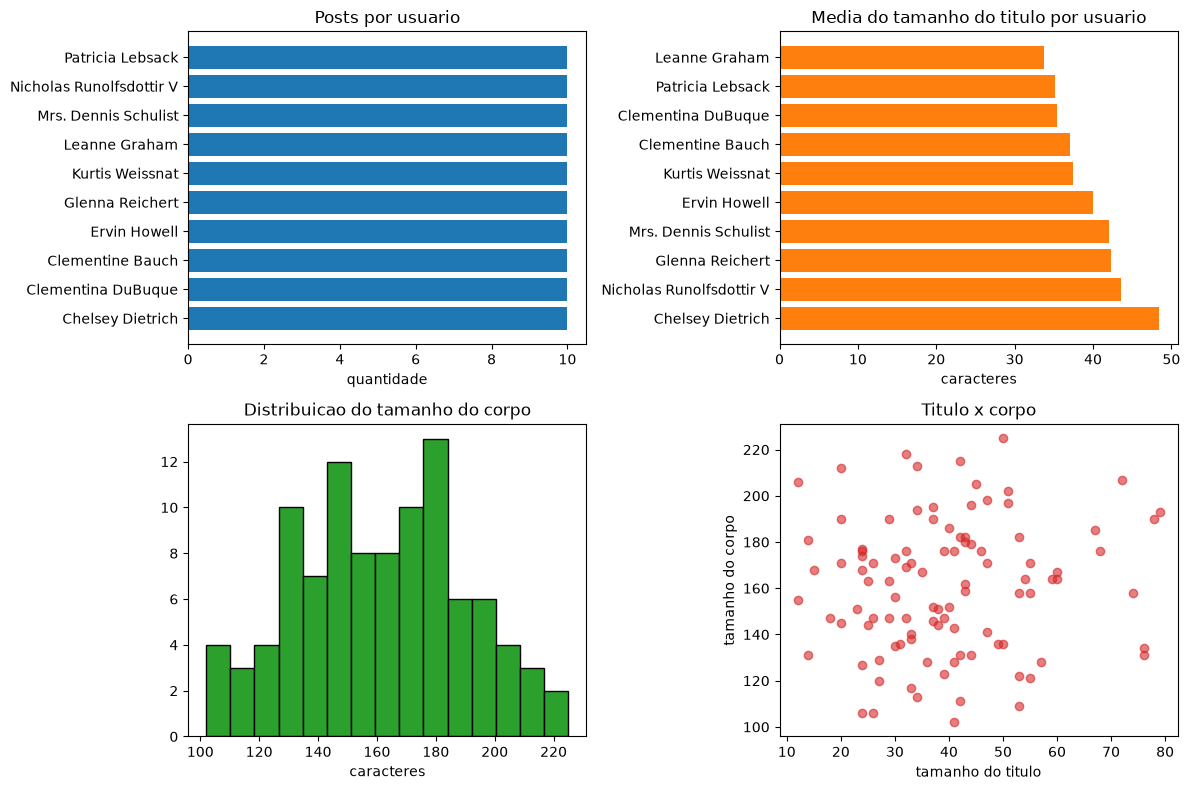

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (0,0) posts por usuario
axes[0, 0].barh(contagem.index, contagem.values, color="tab:blue")
axes[0, 0].set_title("Posts por usuario")
axes[0, 0].set_xlabel("quantidade")

# (0,1) media de tamanho de titulo
axes[0, 1].barh(media_titulo.index, media_titulo.values, color="tab:orange")
axes[0, 1].set_title("Media do tamanho do titulo por usuario")
axes[0, 1].set_xlabel("caracteres")

# (1,0) distribuicao do tamanho do corpo
axes[1, 0].hist(df["tamanho_corpo"], bins=15, color="tab:green", edgecolor="black")
axes[1, 0].set_title("Distribuicao do tamanho do corpo")
axes[1, 0].set_xlabel("caracteres")

# (1,1) dispersao titulo x corpo
axes[1, 1].scatter(df["tamanho_titulo"], df["tamanho_corpo"], alpha=0.6, color="tab:red")
axes[1, 1].set_title("Titulo x corpo")
axes[1, 1].set_xlabel("tamanho do titulo")
axes[1, 1].set_ylabel("tamanho do corpo")

plt.tight_layout()
plt.show()

## 6. Exportacao

Salvamos o DataFrame consolidado em CSV para uso posterior.

In [10]:
import os
from datetime import datetime, timezone

os.makedirs("dados", exist_ok=True)
agora = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
caminho = f"dados/analise_posts_{agora}.csv"
df.to_csv(caminho, index=False, encoding="utf-8")
print("Salvo em:", caminho)

Salvo em: dados/analise_posts_20260919_124048.csv


## Exercicios

1. Repita o fluxo para o recurso /comments e calcule quantos comentarios
   cada post recebeu em media.
2. Junte posts com comentarios e descubra o usuario cujos posts recebem
   mais comentarios.
3. Busque os albuns (/albums) e as fotos (/photos) e descubra qual album
   tem mais fotos.
4. Faca um grafico de barras com a contagem de fotos por album.
5. Trate o caso de a API retornar erro 500 simulando com uma URL invalida
   e verifique se o codigo continua rodando.
6. Exporte o resultado final em JSON e em CSV.
7. Adicione uma coluna "tem_exclamacao" indicando se o titulo termina com
   "!" e agrupe por essa coluna.